In [1]:
# --! include root folder into PYTHONPATH ---------------------------------!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

In [2]:
import torch

import care
import utils_plot

In [3]:
# --!--------------------------------------------------------------------------
# --! load trained models

# --! ensure reproducible results
seed = 5
torch.manual_seed(seed)

model = torch.load('../../models/kalman/kind_sim.pt', weights_only=False)

model.eval()

model(
  (operator_sta): operator_stationary(
    (enc): fcnn(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=20, out_features=64, bias=True)
          (1): ReLU()
        )
        (1): Sequential(
          (0): Linear(in_features=64, out_features=64, bias=True)
          (1): ReLU()
        )
        (2): Sequential(
          (0): Linear(in_features=64, out_features=160, bias=True)
          (1): Identity()
        )
      )
    )
    (model): Linear(in_features=6, out_features=6, bias=False)
    (dec_mean): fcnn(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=6, out_features=64, bias=True)
          (1): ReLU()
        )
        (1): Sequential(
          (0): Linear(in_features=64, out_features=64, bias=True)
          (1): ReLU()
        )
        (2): Sequential(
          (0): Linear(in_features=64, out_features=20, bias=True)
          (1): Identity()
        )
      )
    )
    (dec_var): fcnn(
      (

Parameter containing:
tensor([[ 0.0138,  0.3501, -0.8159,  0.5603,  0.0346, -0.2426],
        [-0.4689,  0.1419,  0.7444,  0.3791, -0.0498,  0.2802],
        [ 0.2482, -0.0169,  0.7393,  0.0511, -0.0416,  0.0287],
        [-0.5720,  0.4399,  0.9683,  0.5173, -0.0674,  0.3862],
        [-0.0090, -0.0028, -0.0597, -0.0181,  0.0020, -0.0191],
        [ 0.0942, -0.3184,  0.3740, -0.2219, -0.0137, -0.0285]])


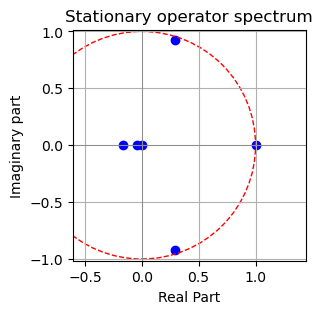

In [4]:
# --!--------------------------------------------------------------------------!
# --! visualize stationary operator eigenvalues

with torch.no_grad():
    utils_plot.plot_eigs(model)

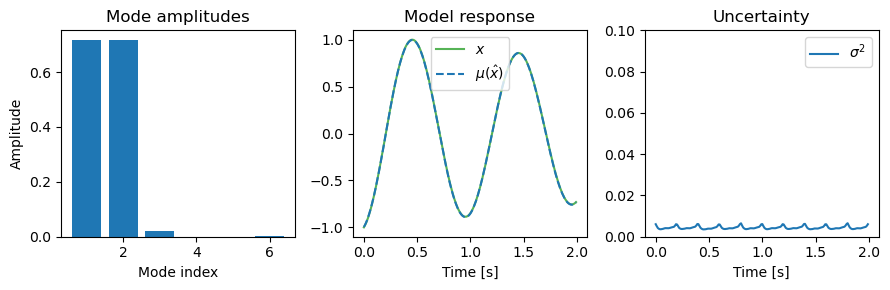

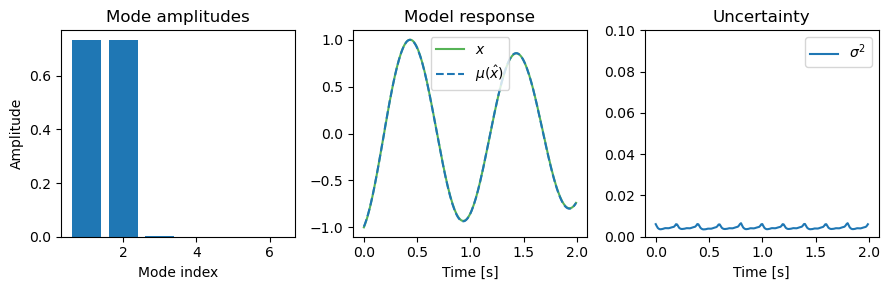

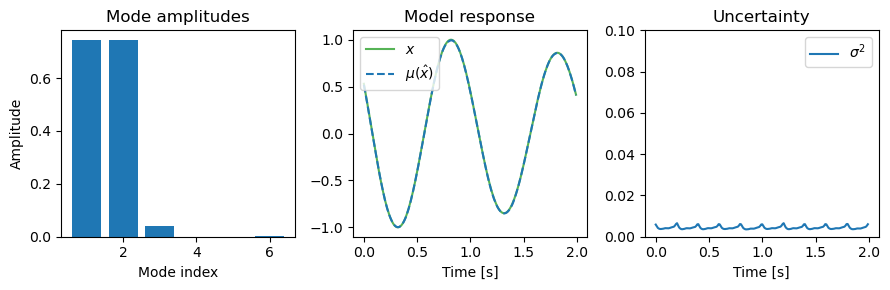

In [5]:
# --!--------------------------------------------------------------------------!
# --! analyze the contribution of stationary operator eigenvalues

datadir            = '../../data/kalman/train_sim_sta'
timeseries_nsample = 200

with torch.no_grad():
    for jtimeseries in range(3):
        utils_plot.plot_modes(model, datadir, timeseries_nsample, jtimeseries)

### KIND model test

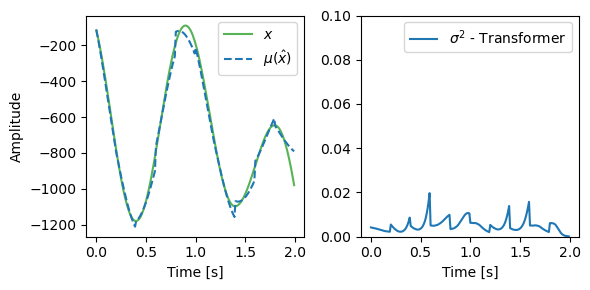

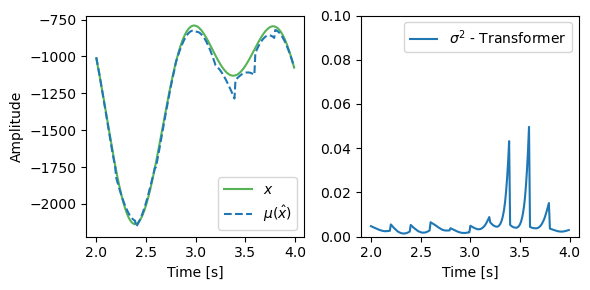

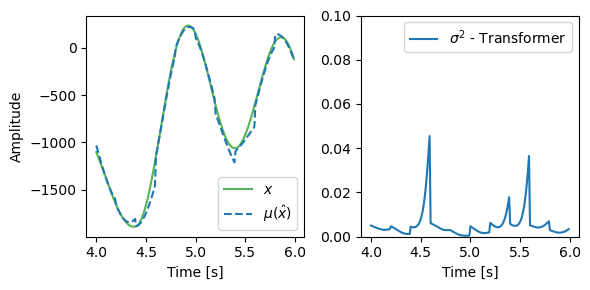

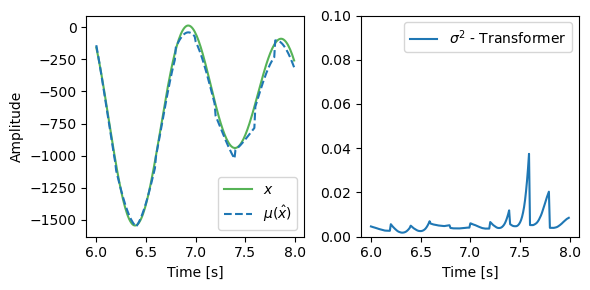

In [6]:
# --!--------------------------------------------------------------------------
# --! evaluate a transient model

with torch.no_grad():
    datadir            = '../../data/kalman/test_sim'
    timeseries_nsample = 200
    utils_plot.plot_transient(model, datadir, timeseries_nsample, datasaved=False)

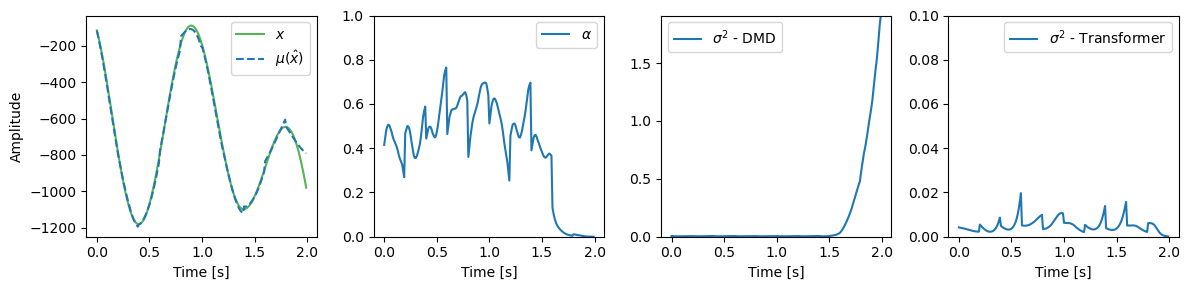

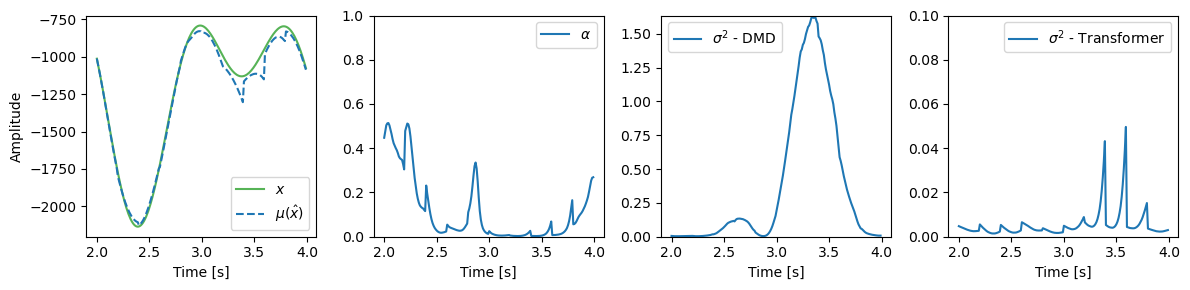

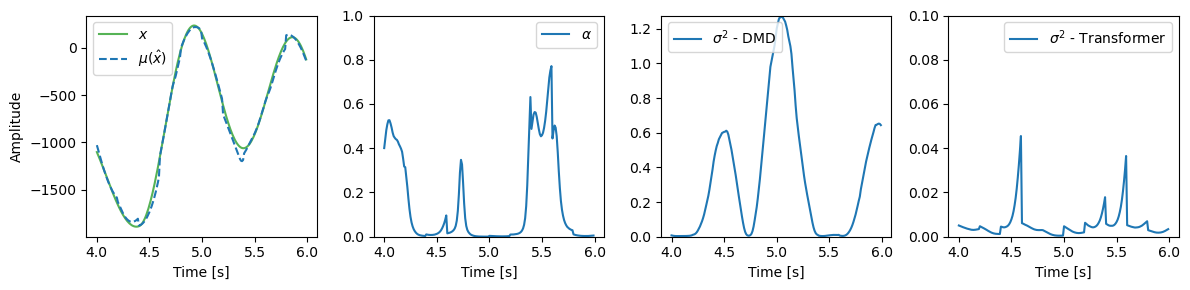

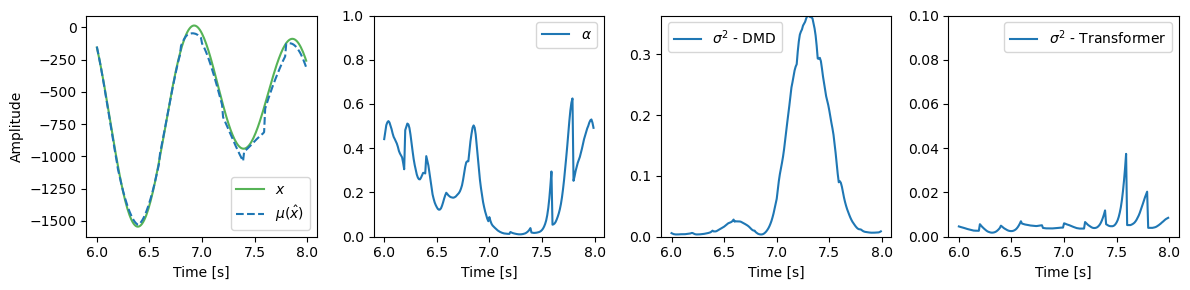

In [7]:
# --!--------------------------------------------------------------------------
# --! test alpha blending

with torch.no_grad():
    datadir            = '../../data/kalman/test_sim'
    timeseries_nsample = 200
    utils_plot.plot_blend(model, datadir, timeseries_nsample, datasaved=False)